In [1]:
import anndata as ad
import scanpy as sc
import numpy as np
import matplotlib.pyplot as plt
import scrublet as scr

In [2]:
p4_adata_egfp = ad.read_h5ad("/blue/square.t/peter.huynh/jupyter/combined_samples_scvelo/p4/data/processed/p4_adata_egfp.h5ad")

In [3]:
adatas = {
    'p4': p4_adata_egfp
}

/blue/square.t/miniconda3/envs/scvelo_033_scrublet/lib/python3.10/site-packages/scanpy/plotting/_anndata.py:842: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  ax = sns.violinplot(


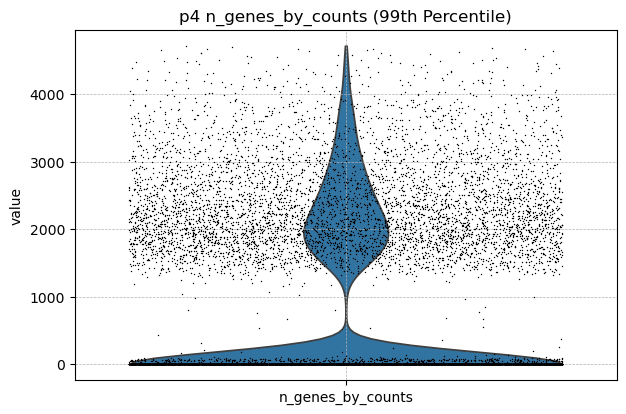

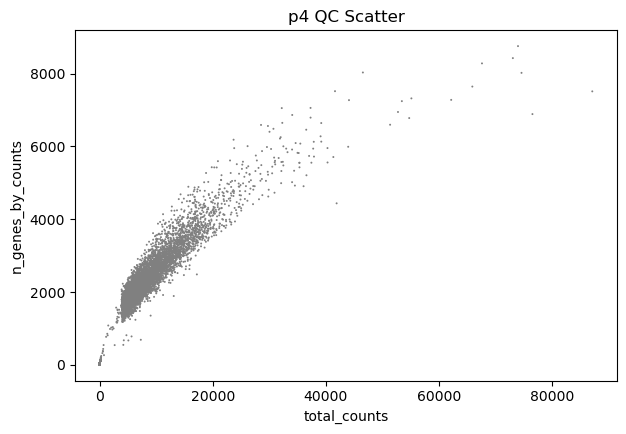

/blue/square.t/miniconda3/envs/scvelo_033_scrublet/lib/python3.10/site-packages/scanpy/plotting/_anndata.py:842: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  ax = sns.violinplot(


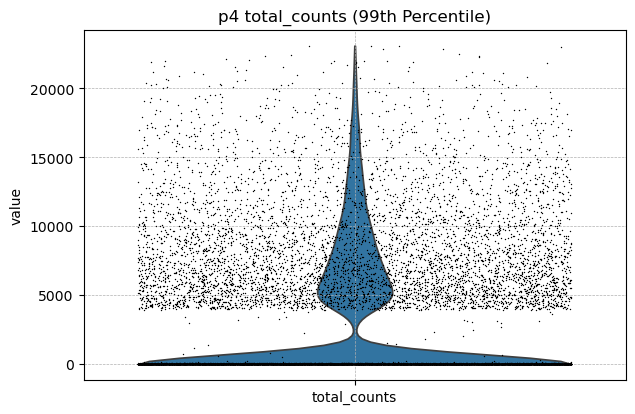

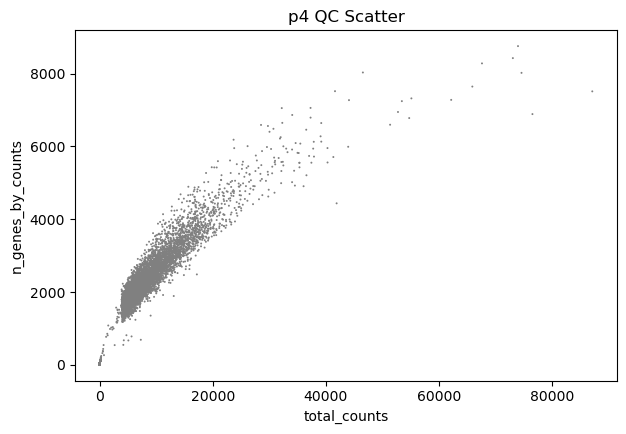

In [4]:
for name, adata in adatas.items():
    counts_cutoff = np.percentile(adata.obs['total_counts'], 99)
    genes_cutoff = np.percentile(adata.obs['n_genes_by_counts'], 99)

    adata_qc = adata[
        (adata.obs['total_counts'] < counts_cutoff) & 
        (adata.obs['n_genes_by_counts'] < genes_cutoff)
    ]

    for feature in ['n_genes_by_counts', 'total_counts']:
        sc.pl.violin(
            adata_qc,
            feature,
            jitter=0.4,
            show=False
        )
        plt.title(f"{name} {feature} (99th Percentile)")
        plt.grid(True, which='both', linestyle='--', linewidth=0.5)
        plt.show()

        sc.pl.scatter(
        adata,
        x='total_counts',
        y='n_genes_by_counts',
        show=True,
        title=f"{name} QC Scatter"
    )

In [4]:
sc.pp.filter_cells(p4_adata_egfp, min_genes=1000)
sc.pp.filter_cells(p4_adata_egfp, max_genes=4000)
p4_adata_egfp = p4_adata_egfp[p4_adata_egfp.obs['total_counts'] < 15000, :] #(Number of UMI per cell)
p4_adata_egfp = p4_adata_egfp[p4_adata_egfp.obs['total_counts'] > 2500, :] #(Number of UMI per cell)
sc.pp.filter_genes(p4_adata_egfp, min_cells=3)
sc.pp.highly_variable_genes(p4_adata_egfp, flavor="seurat_v3", n_top_genes=2000, subset=True)

/blue/square.t/miniconda3/envs/scvelo_033_scrublet/lib/python3.10/site-packages/scanpy/preprocessing/_simple.py:250: ImplicitModificationWarning: Trying to modify attribute `.var` of view, initializing view as actual.
  adata.var['n_cells'] = number


In [5]:
adatas = {
    'p4': p4_adata_egfp
}

In [6]:
adatas

{'p4': AnnData object with n_obs × n_vars = 5331 × 2000
     obs: 'sample', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'n_genes'
     var: 'Accession', 'Chromosome', 'End', 'Start', 'Strand', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
     uns: 'hvg'
     layers: 'ambiguous', 'matrix', 'spliced', 'unspliced'}

In [7]:
import io, numpy as np
from contextlib import redirect_stdout, redirect_stderr
from scipy import sparse
import matplotlib.pyplot as plt

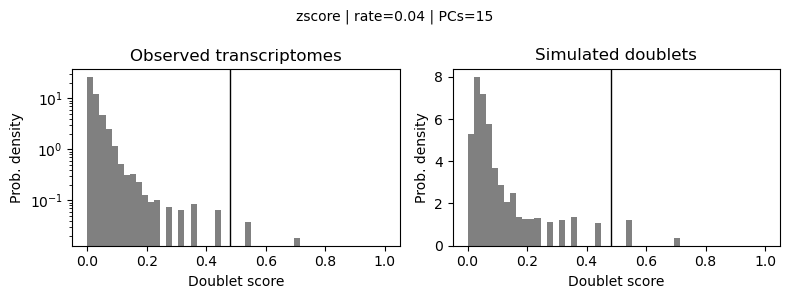

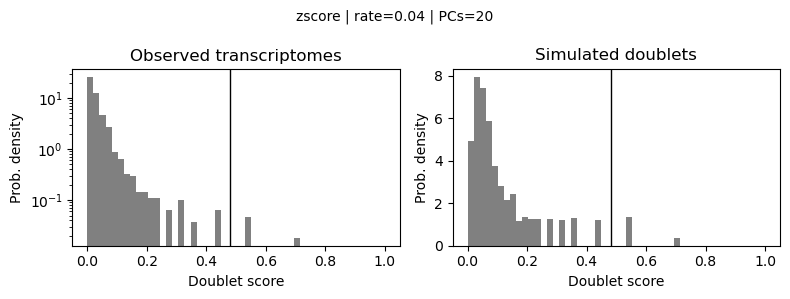

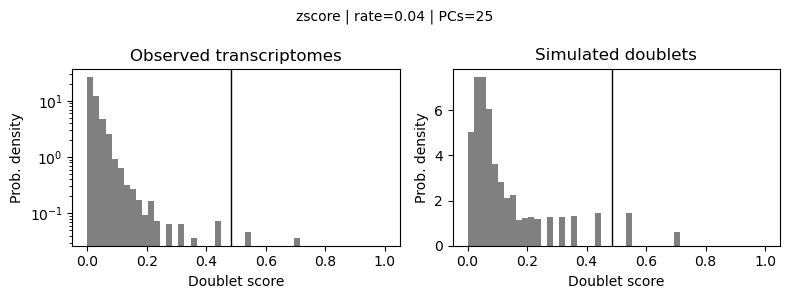

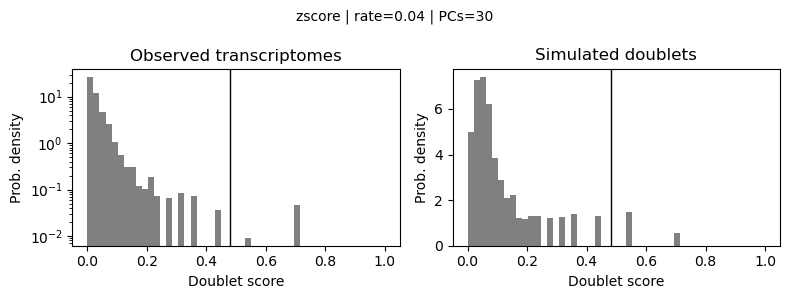

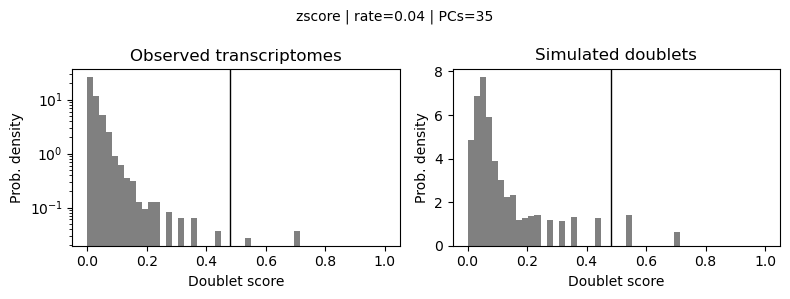

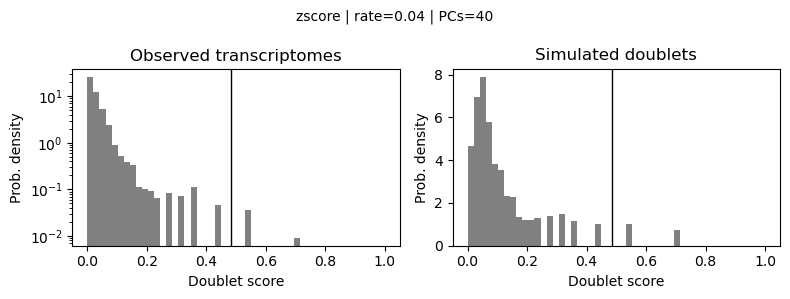

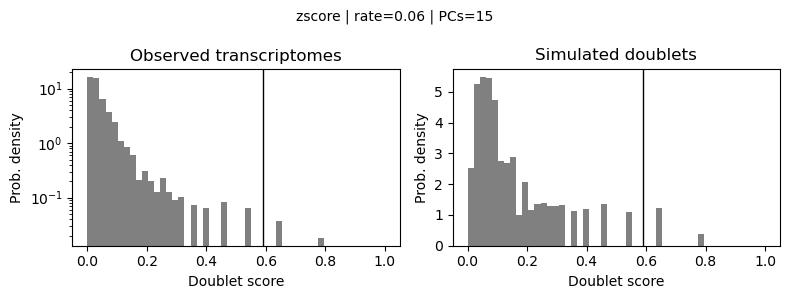

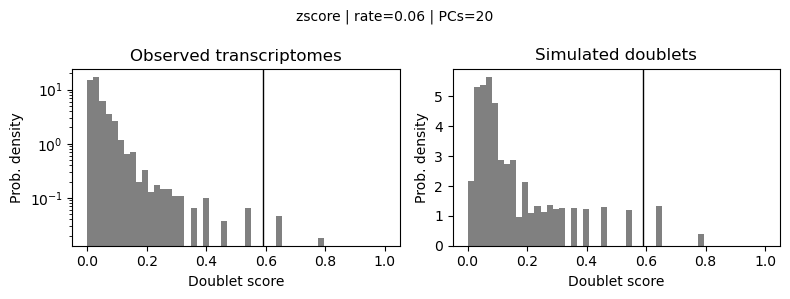

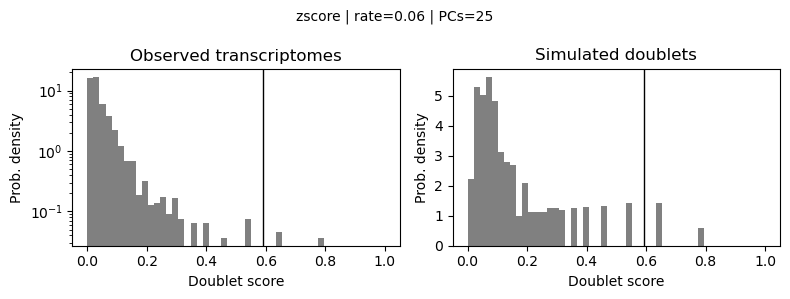

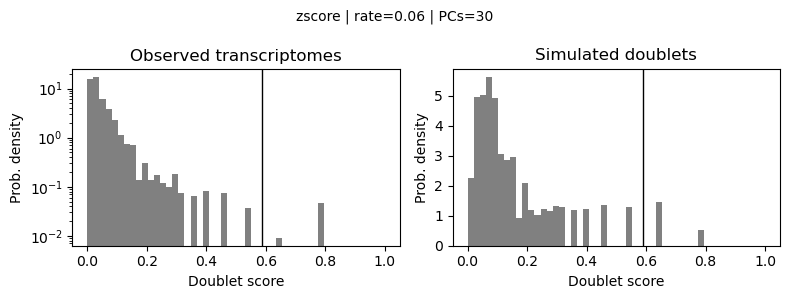

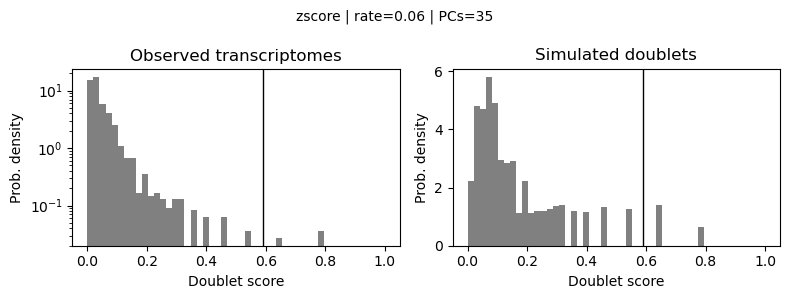

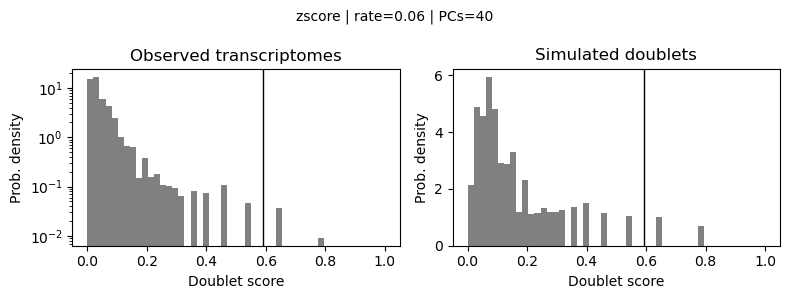

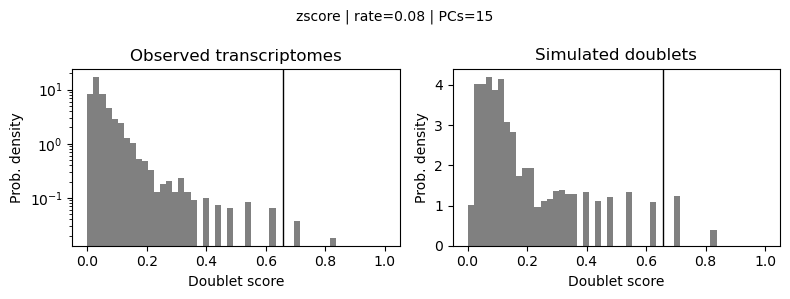

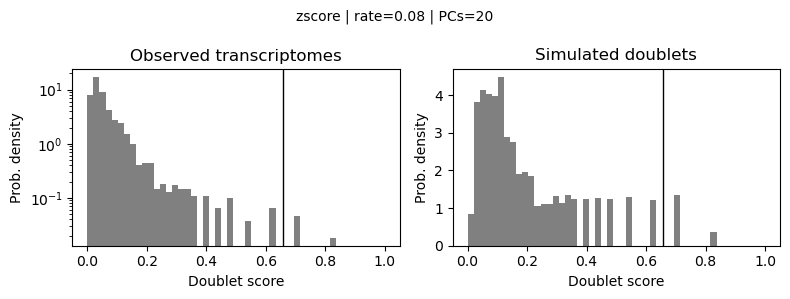

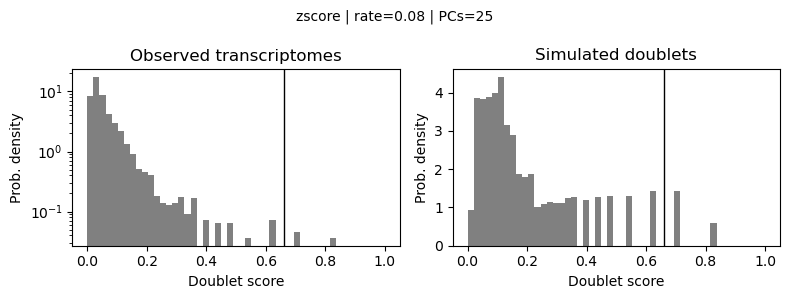

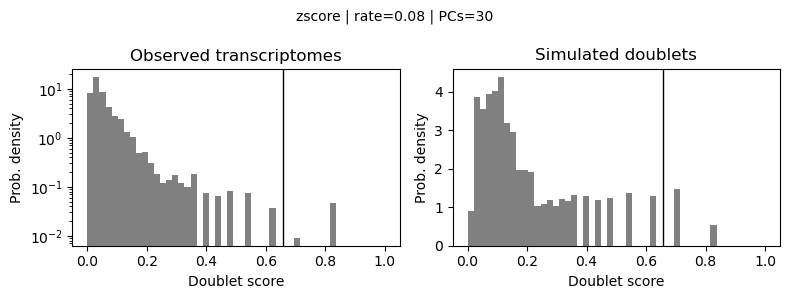

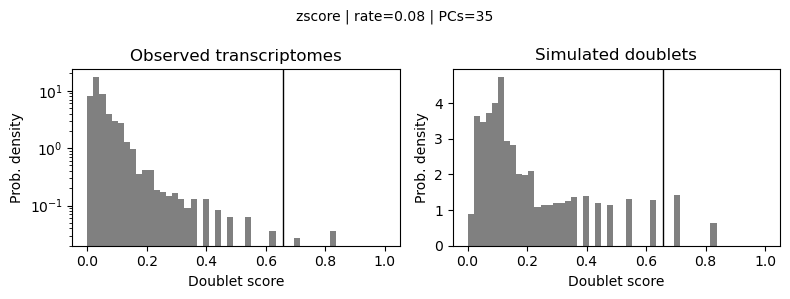

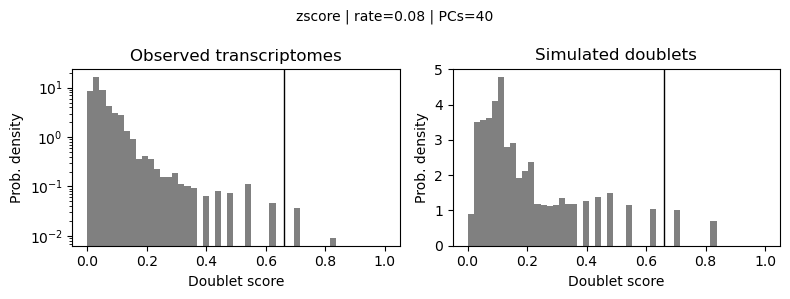

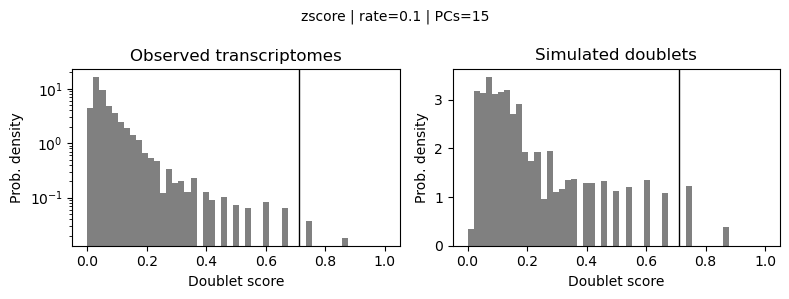

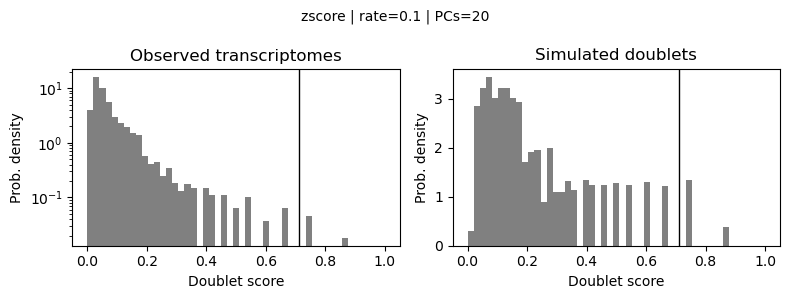

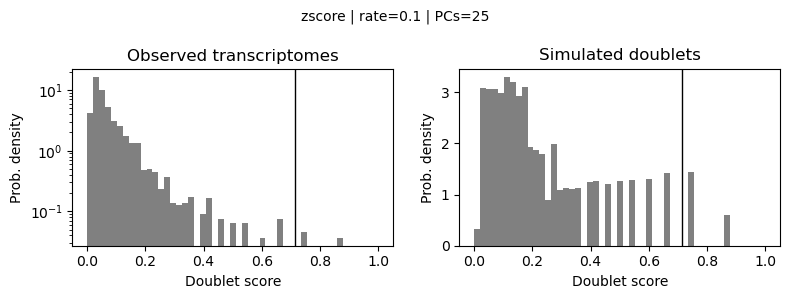

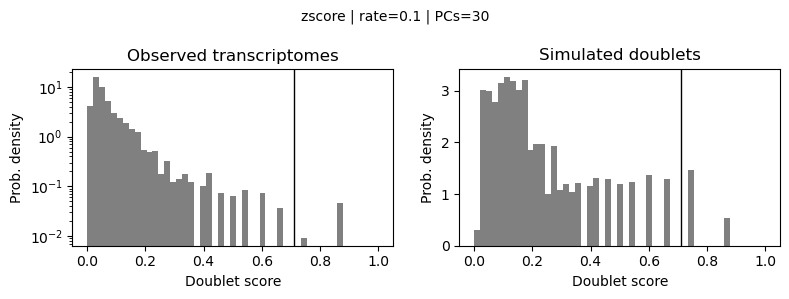

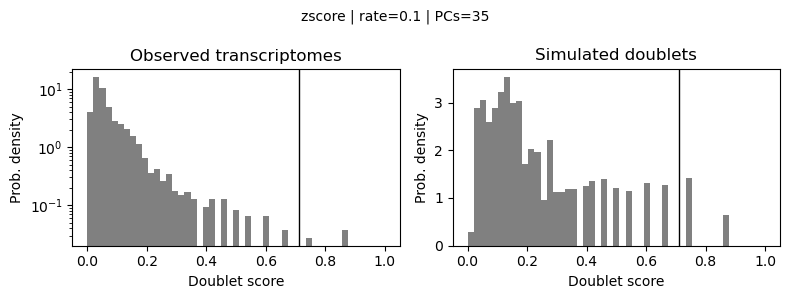

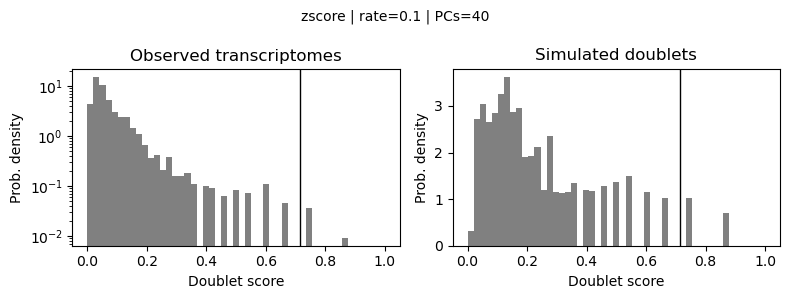

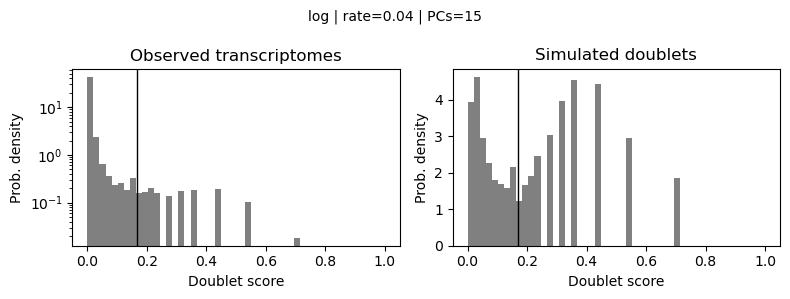

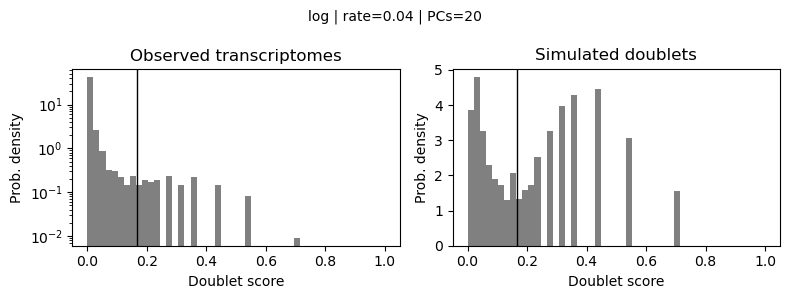

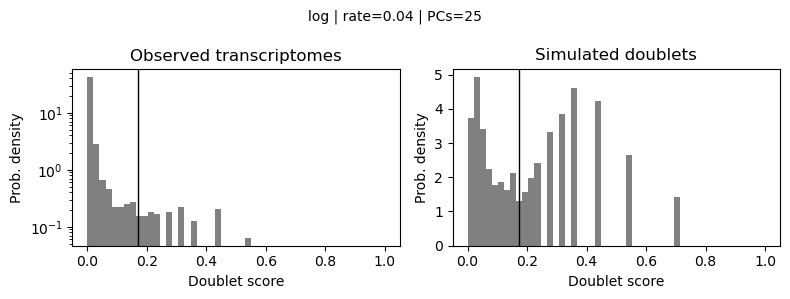

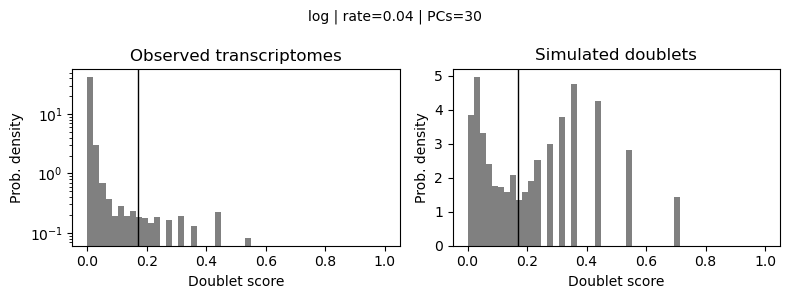

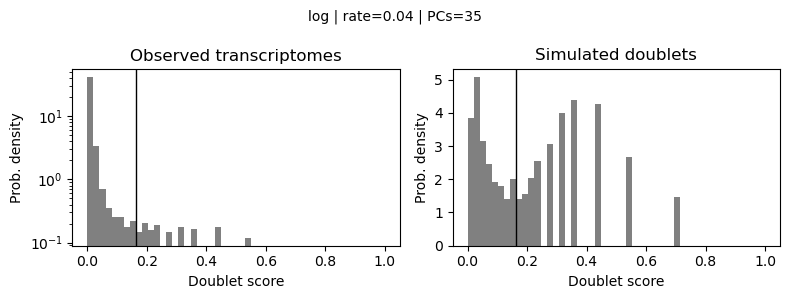

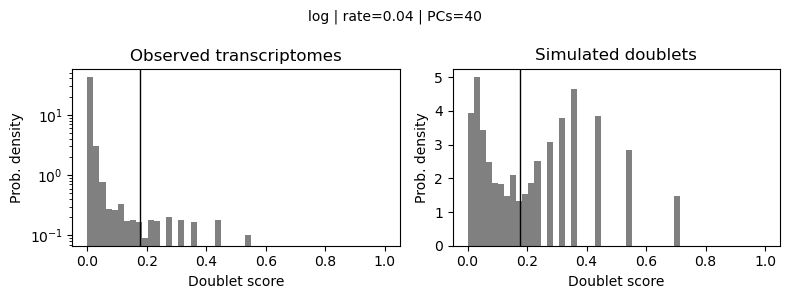

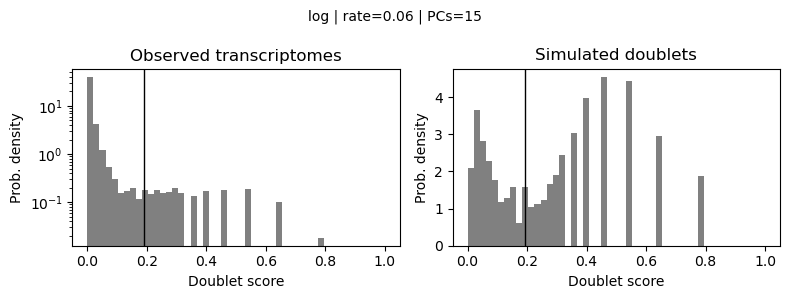

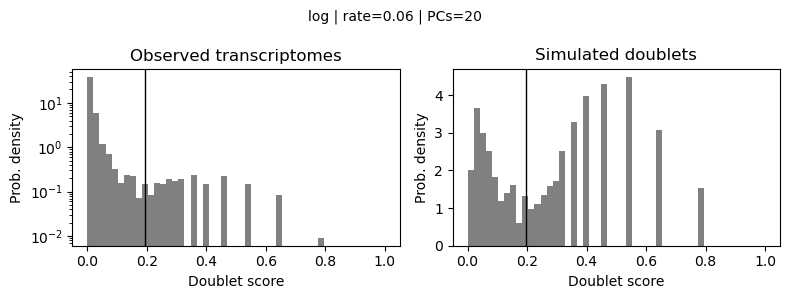

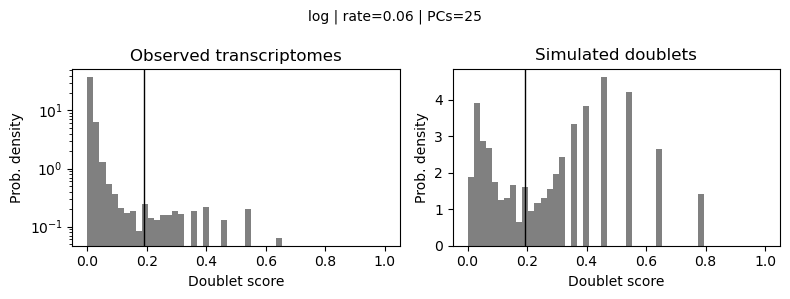

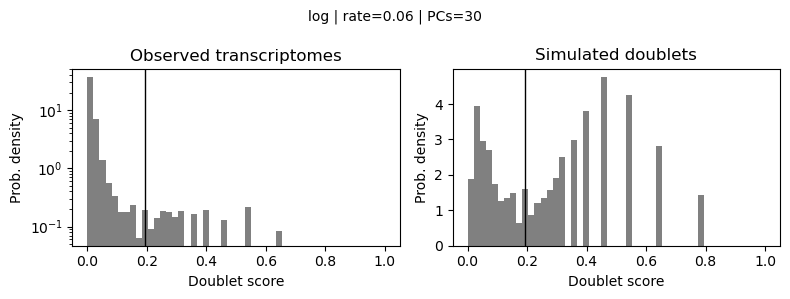

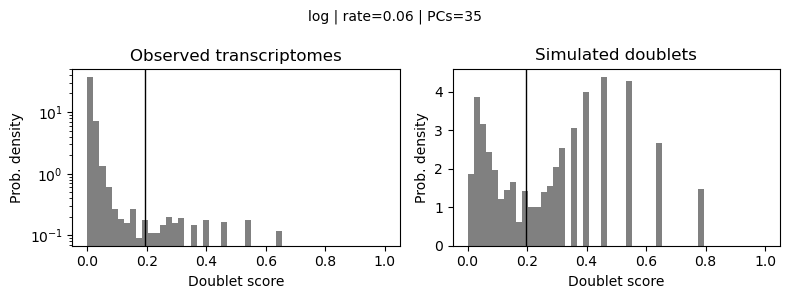

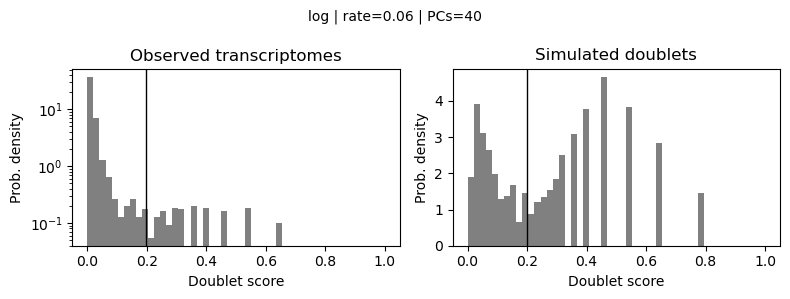

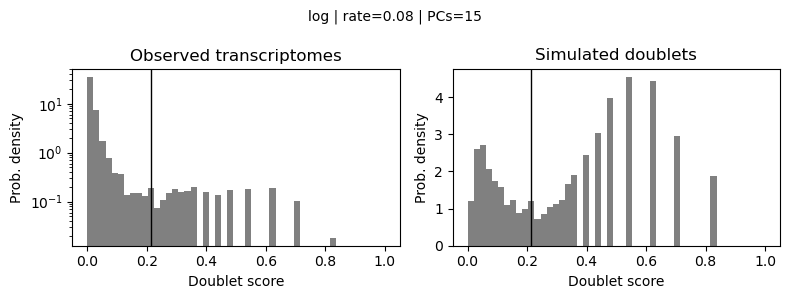

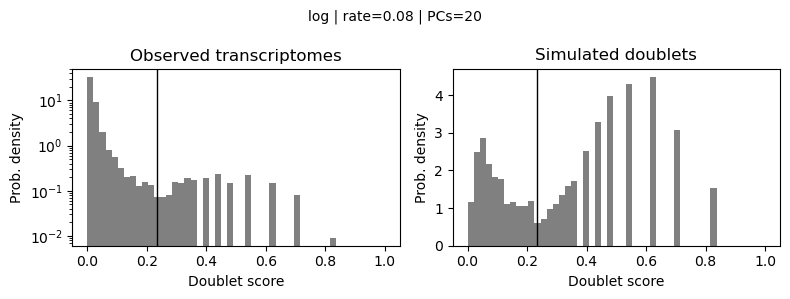

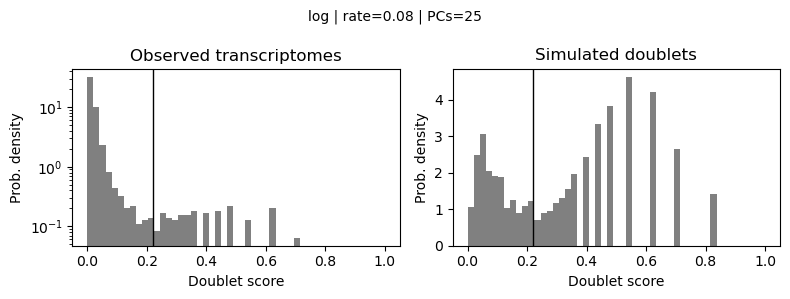

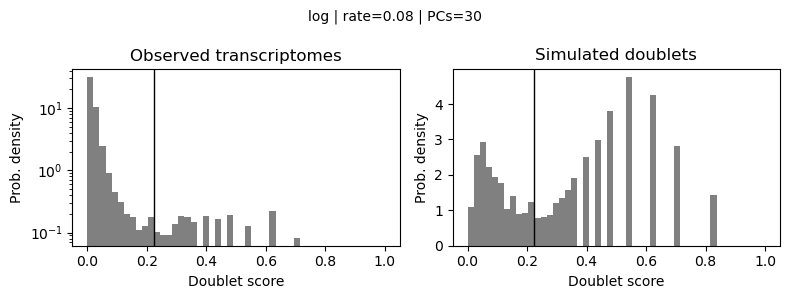

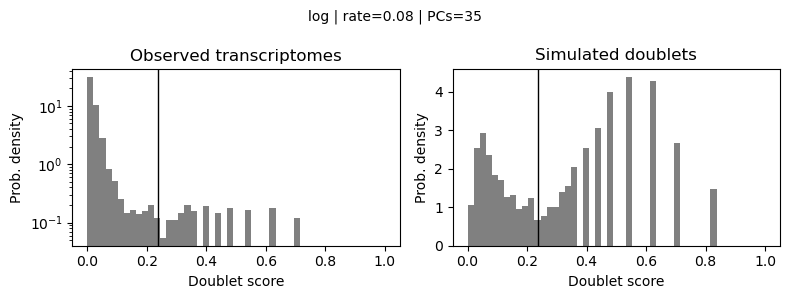

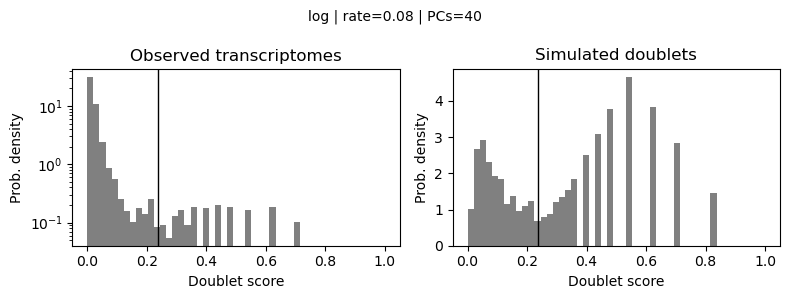

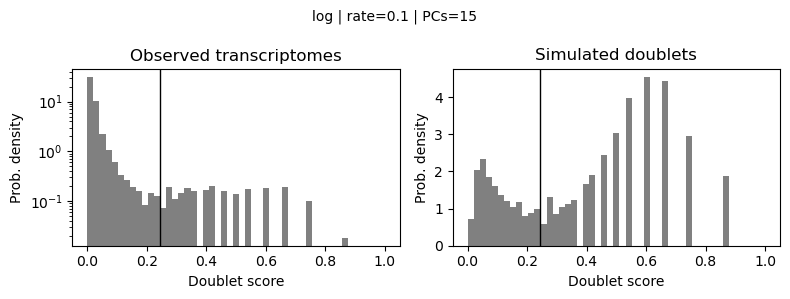

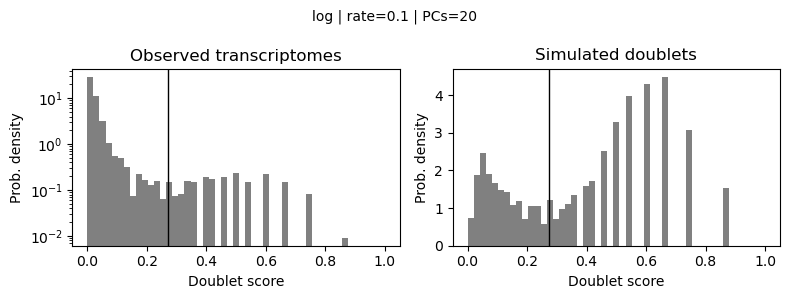

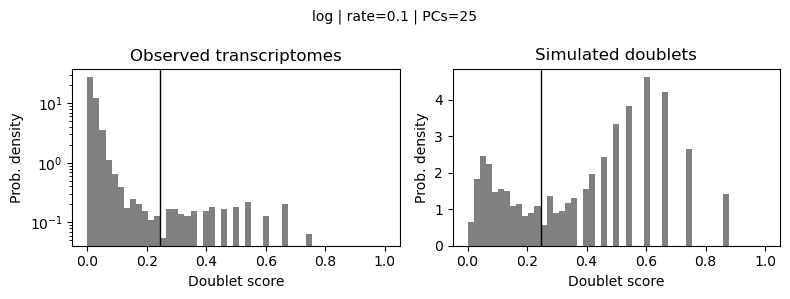

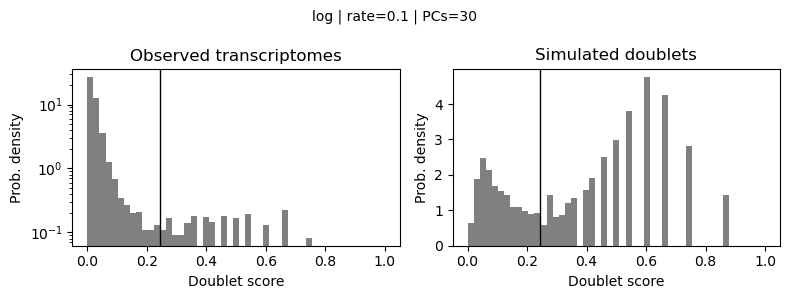

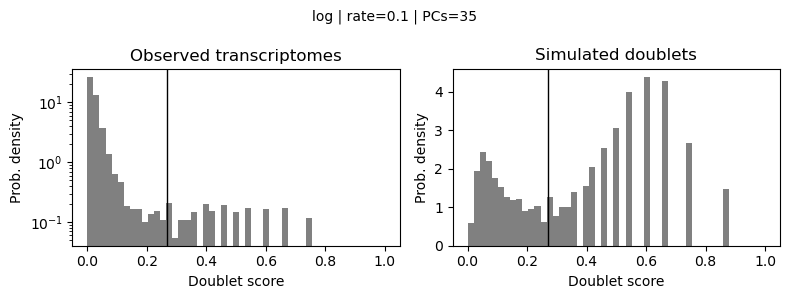

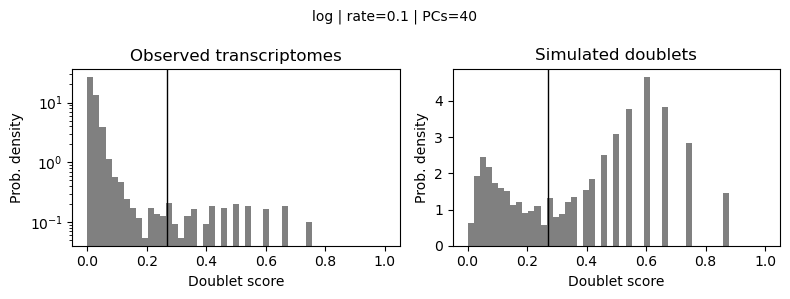

In [8]:
adata = p4_adata_egfp
expected_rates = (0.04, 0.06, 0.08, 0.10)
pcs_list       = (15, 20, 25, 30, 35, 40)
methods        = ('zscore', 'log')
seed           = 13
# --------------

M = adata.X if sparse.isspmatrix_csr(adata.X) else adata.X.tocsr()
np.random.seed(seed)

for method in methods:
    for rate in expected_rates:
        for pcs in pcs_list:
            with redirect_stdout(io.StringIO()), redirect_stderr(io.StringIO()):
                scrub = scr.Scrublet(M, expected_doublet_rate=rate)
                scores, preds = scrub.scrub_doublets(
                    n_prin_comps=pcs,
                    mean_center=(method == 'zscore'),
                    normalize_variance=(method == 'zscore'),
                    log_transform=(method == 'log')
                )

            # Let Scrublet create its own two-panel figure (observed + simulated)
            scrub.plot_histogram()

            # Add a concise descriptor to that figure
            fig = plt.gcf()
            fig.suptitle(f"{method} | rate={rate} | PCs={pcs}", y=0.98, fontsize=10)
            fig.tight_layout()
            plt.show()

In [9]:
adatas

{'p4': AnnData object with n_obs × n_vars = 5331 × 2000
     obs: 'sample', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'n_genes'
     var: 'Accession', 'Chromosome', 'End', 'Start', 'Strand', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
     uns: 'hvg'
     layers: 'ambiguous', 'matrix', 'spliced', 'unspliced'}

In [10]:
scrublet_params = {
    'p4': {'expected_rate': 0.04, 'log_transform': True, 'threshold': 0.2}
}

In [11]:
adatas_clean = {}

for name, adata in adatas.items():
    params = scrublet_params[name]
    
    counts_matrix = adata.X.copy()
    if not isinstance(counts_matrix, np.ndarray):
        counts_matrix = counts_matrix.toarray()
    
    scrub = scr.Scrublet(counts_matrix, expected_doublet_rate=params['expected_rate'])
    
    doublet_scores, predicted_doublets = scrub.scrub_doublets(
        n_prin_comps=40,
        mean_center=not params['log_transform'],
        normalize_variance=not params['log_transform'],
        log_transform=params['log_transform']
    )
    
    scrub.call_doublets(threshold=params['threshold'])
    
    adata.obs['doublet_score'] = scrub.doublet_scores_obs_
    adata.obs['predicted_doublet'] = scrub.predicted_doublets_
    
    adatas_clean[name] = adata[adata.obs['predicted_doublet'] == False].copy()

Preprocessing...
Simulating doublets...
Embedding transcriptomes using Truncated SVD...
Calculating doublet scores...
Automatically set threshold at doublet score = 0.18
Detected doublet rate = 2.6%
Estimated detectable doublet fraction = 52.2%
Overall doublet rate:
	Expected   = 4.0%
	Estimated  = 5.0%
Elapsed time: 3.5 seconds
Detected doublet rate = 2.4%
Estimated detectable doublet fraction = 49.1%
Overall doublet rate:
	Expected   = 4.0%
	Estimated  = 5.0%


In [12]:
adatas

{'p4': AnnData object with n_obs × n_vars = 5331 × 2000
     obs: 'sample', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'n_genes', 'doublet_score', 'predicted_doublet'
     var: 'Accession', 'Chromosome', 'End', 'Start', 'Strand', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
     uns: 'hvg'
     layers: 'ambiguous', 'matrix', 'spliced', 'unspliced'}

In [13]:
adatas_clean

{'p4': AnnData object with n_obs × n_vars = 5201 × 2000
     obs: 'sample', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'n_genes', 'doublet_score', 'predicted_doublet'
     var: 'Accession', 'Chromosome', 'End', 'Start', 'Strand', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
     uns: 'hvg'
     layers: 'ambiguous', 'matrix', 'spliced', 'unspliced'}

In [14]:
adata_combined = ad.concat(
    adatas_clean.values(),
    label="sample",
    keys=adatas_clean.keys()
)

In [15]:
egfp_idx = adata_combined.var_names.get_loc("egfp")
egfp_counts = adata_combined.X[:, egfp_idx]
print((egfp_counts > 0).sum())

44


In [16]:
adata_combined

AnnData object with n_obs × n_vars = 5201 × 2000
    obs: 'sample', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'n_genes', 'doublet_score', 'predicted_doublet'
    layers: 'ambiguous', 'matrix', 'spliced', 'unspliced'

In [17]:
adata_combined.write("/blue/square.t/peter.huynh/jupyter/combined_samples_scvelo/p4/data/processed/p4_adata_scrubleted_egfp.h5ad")